In [4]:
# !unzip TelcoCustomerChurn.zip

In [ ]:
# %pip install pandas scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# %pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [8]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Explanation of Columns

| Column Name | Description |
| :--- | :--- |
| **customerID** | A unique ID that identifies each individual customer. |
| **gender** | Whether the customer is a male or a female. |
| **SeniorCitizen** | Indicates if the customer is a senior citizen (1: Yes, 0: No). |
| **Partner** | Whether the customer has a partner (Yes, No). |
| **Dependents** | Whether the customer has dependents (Yes, No). |
| **tenure** | Number of months the customer has stayed with the company. |
| **PhoneService** | Whether the customer has a phone service (Yes, No). |
| **MultipleLines** | Whether the customer has multiple lines (Yes, No, No phone service). |
| **InternetService** | Customer’s internet service provider (DSL, Fiber optic, No). |
| **OnlineSecurity** | Whether the customer has online security (Yes, No, No internet service). |
| **OnlineBackup** | Whether the customer has online backup (Yes, No, No internet service). |
| **DeviceProtection** | Whether the customer has device protection (Yes, No, No internet service). |
| **TechSupport** | Whether the customer has tech support (Yes, No, No internet service). |
| **StreamingTV** | Whether the customer has streaming TV (Yes, No, No internet service). |
| **StreamingMovies** | Whether the customer has streaming movies (Yes, No, No internet service). |
| **Contract** | The contract term of the customer (Month-to-month, One year, Two year). |
| **PaperlessBilling** | Whether the customer has paperless billing (Yes, No). |
| **PaymentMethod** | The customer’s payment method (Electronic check, Mailed check, Bank transfer, Credit card). |
| **MonthlyCharges** | The amount charged to the customer monthly. |
| **TotalCharges** | The total amount charged to the customer. |
| **Churn** | **Target Variable**: Whether the customer churned (left the company) or not (Yes or No). |

In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [10]:
df = df.drop(['customerID', 'gender'], axis=1)

In [11]:
df.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'],
      dtype='str')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     7043 non-null   int64  
 1   Partner           7043 non-null   str    
 2   Dependents        7043 non-null   str    
 3   tenure            7043 non-null   int64  
 4   PhoneService      7043 non-null   str    
 5   MultipleLines     7043 non-null   str    
 6   InternetService   7043 non-null   str    
 7   OnlineSecurity    7043 non-null   str    
 8   OnlineBackup      7043 non-null   str    
 9   DeviceProtection  7043 non-null   str    
 10  TechSupport       7043 non-null   str    
 11  StreamingTV       7043 non-null   str    
 12  StreamingMovies   7043 non-null   str    
 13  Contract          7043 non-null   str    
 14  PaperlessBilling  7043 non-null   str    
 15  PaymentMethod     7043 non-null   str    
 16  MonthlyCharges    7043 non-null   float64
 17  TotalC

In [13]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for any new null values created during conversion
print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Verify the new data type
print(df['TotalCharges'].dtype)

Missing values in TotalCharges: 11
float64


In [14]:
print(len(df))

7043


In [15]:
df.isna().sum()

SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [16]:
df = df.dropna()

In [17]:
df.isna().sum()

SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [18]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


### Step 1: Binary Encoding
We'll map 'Yes' to 1 and 'No' (including variants like 'No internet service') to 0 for binary features.

In [19]:
import pandas as pd

# Strictly binary columns (only Yes/No)
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

# Columns that have 'No internet service' or 'No phone service' as a distinct third category
service_detail_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Standard categorical columns
multi_class_cols = ['InternetService', 'Contract', 'PaymentMethod']

# 1. Map strictly binary columns to 0/1
for col in binary_cols:
    df[col] = df[col].replace({'Yes': 1, 'No': 0}).astype(int)

# 2. Use One-Hot Encoding for everything else, explicitly setting dtype to int
cols_to_encode = service_detail_cols + multi_class_cols
df = pd.get_dummies(data=df, columns=cols_to_encode, dtype=int)

print(f"New shape of dataframe: {df.shape}")
display(df.head())

New shape of dataframe: (7032, 40)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,0,...,1,0,0,1,0,0,0,0,1,0
1,0,0,0,34,1,0,56.95,1889.50,0,1,...,1,0,0,0,1,0,0,0,0,1
2,0,0,0,2,1,1,53.85,108.15,1,1,...,1,0,0,1,0,0,0,0,0,1
3,0,0,0,45,0,0,42.30,1840.75,0,0,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,2,1,1,70.70,151.65,1,1,...,0,1,0,1,0,0,0,0,1,0


### Data Ready for Modeling
The categorical variables have been encoded while preserving the distinction between 'No' and 'No Service'. The dataset is now numerically encoded.

In [20]:
# Final check of the encoded features
print(f"Total columns: {len(df.columns)}")
print("Sample of new service-specific columns:")
display(df.filter(like='No internet service').head())

Total columns: 40
Sample of new service-specific columns:


,OnlineSecurity_No internet service,OnlineBackup_No internet service,DeviceProtection_No internet service,TechSupport_No internet service,StreamingTV_No internet service,StreamingMovies_No internet service
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


### Scaling Numerical Features
We use `StandardScaler` to normalize the numerical columns ('tenure', 'MonthlyCharges', 'TotalCharges') so they have a mean of 0 and a standard deviation of 1.

### What is StandardScaler?

**StandardScaler** is a preprocessing technique used to standardize features by:
1.  **Centering**: Subtracting the mean of each feature so it becomes 0.
2.  **Scaling**: Dividing by the standard deviation so the feature has a unit variance (1).

**Why is it used?**
*   **Prevents Bias**: Algorithms like Logistic Regression, SVM, and KNN are sensitive to the magnitude of numbers. Scaling prevents features with large values (like `TotalCharges`) from dominating those with smaller values (like `tenure`).
*   **Faster Convergence**: Gradient-based optimizers (used in Neural Networks) converge much faster when features are on a similar scale.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Scale the numerical columns
df[num_cols] = scaler.fit_transform(df[num_cols])

print("Numerical columns scaled successfully.")
display(df[num_cols].head())

Numerical columns scaled successfully.


,tenure,MonthlyCharges,TotalCharges
0,-1.280248,-1.161694,-0.994194
1,0.064303,-0.260878,-0.173740
2,-1.239504,-0.363923,-0.959649
3,0.512486,-0.747850,-0.195248
4,-1.239504,0.196178,-0.940457


In [22]:
x = df.drop(['Churn'], axis=1)
y = df['Churn']

In [23]:
# Fixing the assignment order: X_train, X_test, y_train, y_test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# %pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.6/101.7 MB 16.4 MB/s eta 0:00:07
   -- ------------------------------------- 6.3/101.7 MB 17.5 MB/s eta 0:00:06
   --- ------------------------------------ 10.0/101.7 MB 18.1 MB/s eta 0:00:06
   ----- ---------------------------------- 14.2/101.7 MB 18.4 MB/s eta 0:00:05
   ------- -------------------------------- 18.1/101.7 MB 18.6 MB/s eta 0:00:05
   -------- ------------------------------- 22.0/101.7 MB 18.7 MB/s eta 0:00:05
   ---------- ----------------------------- 26.2/101.7 MB 18.8 MB/s eta 0:00:05
   ----------- ---------------------------- 30.1/101.7 MB 18.9 MB/s eta 0:00:04
   ------------- -------------------------- 34.1/101.7 MB 18.9 MB/s eta 0:00:04
   -------------- ------------------------- 38.0/101.7 MB 18.9 MB/s eta 0:00:04
   ---------------- ----------------------- 41.9/101.7 MB 19.0 MB/s eta 0:00:04
   ------------------ --------------------- 45.9/10

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Using Classifiers instead of Regressors
log_reg = LogisticRegression(max_iter=1000)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Fit models
log_reg.fit(x_train, y_train)
rf_clf.fit(x_train, y_train)
xgb_clf.fit(x_train, y_train)

print("Classification models trained successfully!")

Classification models trained successfully!


d:\AQ\Projects\TelcoCustomerChurn_ML-Project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [07:22:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [27]:
from sklearn.metrics import accuracy_score

# Evaluate Accuracy
models = {
    "Logistic Regression": log_reg,
    "Random Forest Classifier": rf_clf,
    "XGBoost Classifier": xgb_clf
}

for name, model in models.items():
    train_acc = accuracy_score(y_train, model.predict(x_train))
    test_acc = accuracy_score(y_test, model.predict(x_test))
    print(f"{name}:")
    print(f"  Training Accuracy: {train_acc:.4f}")
    print(f"  Testing Accuracy:  {test_acc:.4f}\n")

Logistic Regression:
  Training Accuracy: 0.8078
  Testing Accuracy:  0.7875

Random Forest Classifier:
  Training Accuracy: 0.9973
  Testing Accuracy:  0.7854

XGBoost Classifier:
  Training Accuracy: 0.9364
  Testing Accuracy:  0.7775



### Improving Generalization with Regularization
To fix the overfitting (high training accuracy vs. lower testing accuracy), we will tune the models by limiting their complexity. We will also use Cross-Validation for a more robust evaluation.

In [28]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score

# Retrain with regularization (e.g., max_depth)
log_reg_optimized = LogisticRegression(max_iter=1000, C=0.1)
rf_clf_optimized = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
xgb_clf_optimized = xgb.XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, eval_metric='logloss')

# Evaluate with 5-fold Cross-Validation using ROC-AUC
models_opt = {
    "Tuned Logistic Regression": log_reg_optimized,
    "Tuned Random Forest": rf_clf_optimized,
    "Tuned XGBoost": xgb_clf_optimized
}

print("Model Performance (ROC-AUC Score):")
for name, model in models_opt.items():
    # Using 'roc_auc' as the scoring parameter
    cv_auc_scores = cross_val_score(model, x, y, cv=5, scoring='roc_auc')
    print(f"{name} CV ROC-AUC: {cv_auc_scores.mean():.4f} (+/- {cv_auc_scores.std() * 2:.4f})")

# Fit the best performer for final validation
rf_clf_optimized.fit(x_train, y_train)
# Predict probabilities for AUC calculation
train_probs = rf_clf_optimized.predict_proba(x_train)[:, 1]
test_probs = rf_clf_optimized.predict_proba(x_test)[:, 1]

print(f"\nOptimized RF Training ROC-AUC: {roc_auc_score(y_train, train_probs):.4f}")
print(f"Optimized RF Testing ROC-AUC: {roc_auc_score(y_test, test_probs):.4f}")

Model Performance (ROC-AUC Score):
Tuned Logistic Regression CV ROC-AUC: 0.8446 (+/- 0.0214)
Tuned Random Forest CV ROC-AUC: 0.8401 (+/- 0.0233)
Tuned XGBoost CV ROC-AUC: 0.8466 (+/- 0.0206)

Optimized RF Training ROC-AUC: 0.9511
Optimized RF Testing ROC-AUC: 0.8281


### Confusion Matrix Visualization
The confusion matrix shows the counts of true positives, true negatives, false positives, and false negatives, giving us a deeper look into model performance beyond just the ROC-AUC score.

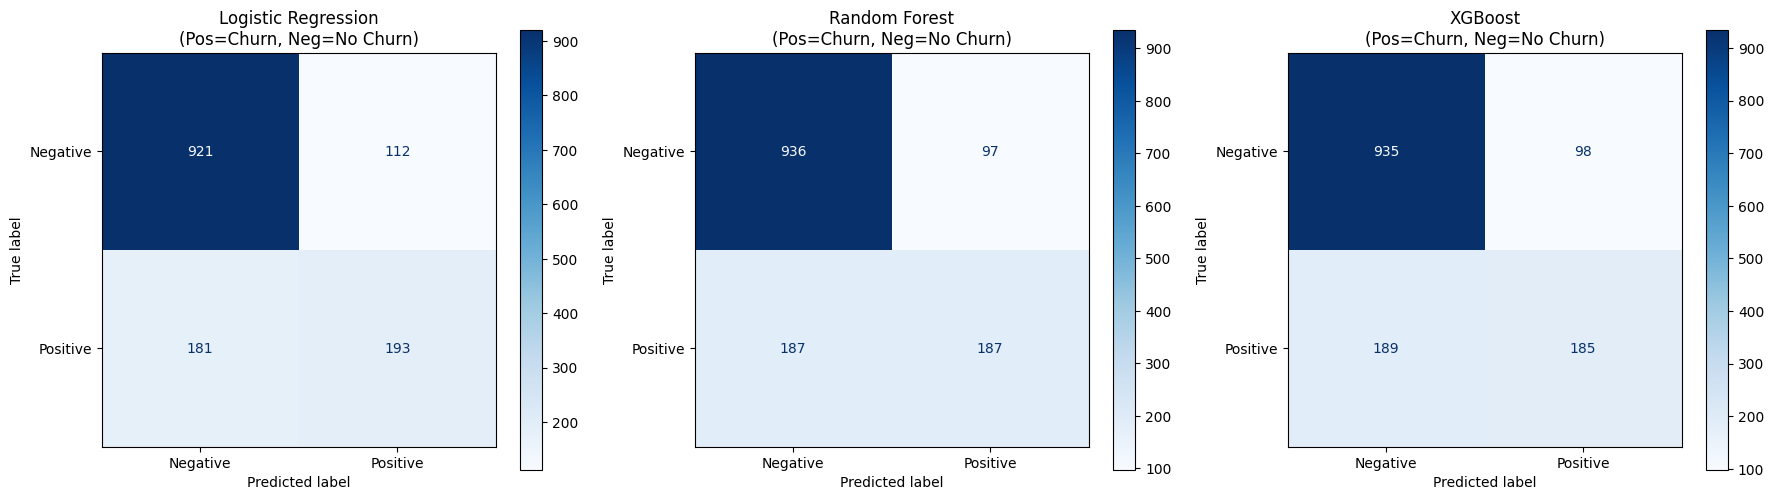

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Ensure models are fitted
log_reg_optimized.fit(x_train, y_train)
rf_clf_optimized.fit(x_train, y_train)
xgb_clf_optimized.fit(x_train, y_train)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_list = [
    ("Logistic Regression", log_reg_optimized),
    ("Random Forest", rf_clf_optimized),
    ("XGBoost", xgb_clf_optimized)
]

# Using 'Positive' for Churn and 'Negative' for No Churn as requested
labels = ['Negative', 'Positive']

for i, (name, model) in enumerate(models_list):
    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f"{name}\n(Pos=Churn, Neg=No Churn)")

plt.tight_layout()
plt.show()